In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

2024-03-05 14:01:40.755932: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-05 14:01:40.828270: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-05 14:01:41.037395: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-05 14:01:41.037436: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-05 14:01:41.038857: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

In [2]:
X=np.load("X.npy") # This input is having sign language images of digits 0 to 9
Y=np.load("Y.npy") # The encoded label outputs of digits 0 to 9

In [3]:
X.shape # There are 2064 images are there in total in this datset. Each image is 64x64 in size

(2062, 64, 64)

In [4]:
X[600,:,:].shape # Accessing one single image (600th Image)

(64, 64)

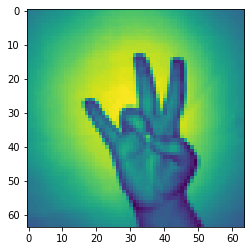

In [5]:
plt.imshow(X[600,:,:]) # Displaying one single image

In [6]:
Y[600] 
# encoded output of 600th image. 
#We can see one at the index position of 2. Hence this is a sign representation of digit 2

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [7]:
Y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [8]:
# Split the data in to train and test
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=48)

In [9]:
xtrain.shape, xtest.shape

((1649, 64, 64), (413, 64, 64))

In [10]:
64*64

4096

In [11]:
Xtrain=xtrain.reshape(1649,64*64) 
# Reshape the matrix image data into a vector
# 64x64 image reshaped into 1x4096
# Totally 1649 images are there in Xtrain, hence now the xtrain size is 1649x4096

In [12]:
Xtrain.shape

(1649, 4096)

In [13]:
Xtest=xtest.reshape(413,64*64) # Simillary reshape the Xtest also

In [14]:
Xtest.shape

(413, 4096)

In [15]:
# Normalize the data between 0 to 1. Image pixels always have the maximum value as 255. 
# Divide each pixel with 255, so the data scaled between 0 to 1
Xtrain1=Xtrain/255.
Xtest1=Xtest/255.

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
img_classifier=Sequential() 
# Define the neural network as a sequentail model (Sequence of layers from input to output)

In [18]:
img_classifier.add(Dense(units=512,activation='relu',input_dim=4096))
# through the function Dense, the layers can be added in to neural networks
#input_dim is having the information about number of neurons in the input layer
# units is having the information about the number of neurons in the output side of that layer.
# units = 512 is nothing but the number of neurons in the first hidden layer 
#( first hidden layer is exist at the output side of input layer)
# 'relu' activation function is prefred always in hidden layers

img_classifier.add(Dense(units=256,activation='relu'))
#units =256 is the number of neurons in the second hidden layer
# input_dim is not required here as it is a sequential model, the network knows that the 
                     #second hidden layer will recieve the input from first hiiden layer (512 neurons)

img_classifier.add(Dense(units=10,activation='softmax'))
#The last dense layer is the output layer.
#The number of neurons in the output layer is number of classes for multiclass problem
# For multi-class problem, Softmax activation function is prefered
#The number of neurons in the output layer is "one" for binary class problem
# For binary class problem, sigmoidal activation function is prefered.

In [19]:
img_classifier.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# For compiling the model, wee need to provide the optimizer detail.
# There are many gradiant decent versions of optimizers are available, here we have used adam
# Loss which the optmizer need to minimize need to be specified.
# For multi-class problem, we need to give categorical_crossentropy as loss 
# For binary class problem, we need to give binary_crossentropy

In [20]:
img_classifier.fit(Xtrain1,ytrain,batch_size=32,epochs=100)
# for the fitting the model we need to provide train input and output
# BAtch size determine for howmany samples once the weights need to be updated (batch gradient descent detail)
# Epochs times the the network run again and agin and update the weights to produce minimum error

Epoch 1/100
52/52 [==============================] - 2s 28ms/step - loss: 2.3051 - accuracy: 0.0898
Epoch 2/100
52/52 [==============================] - 1s 27ms/step - loss: 2.3004 - accuracy: 0.1170
Epoch 3/100
52/52 [==============================] - 1s 27ms/step - loss: 2.2924 - accuracy: 0.1213
Epoch 4/100
52/52 [==============================] - 1s 28ms/step - loss: 2.2616 - accuracy: 0.2523
Epoch 5/100
52/52 [==============================] - 1s 27ms/step - loss: 2.1740 - accuracy: 0.2395
Epoch 6/100
52/52 [==============================] - 1s 28ms/step - loss: 2.0137 - accuracy: 0.2978
Epoch 7/100
52/52 [==============================] - 1s 27ms/step - loss: 1.8428 - accuracy: 0.3790
Epoch 8/100
52/52 [==============================] - 1s 28ms/step - loss: 1.6872 - accuracy: 0.4166
Epoch 9/100
52/52 [==============================] - 1s 28ms/step - loss: 1.5878 - accuracy: 0.4324
Epoch 10/100
52/52 [==============================] - 1s 28ms/step - loss: 1.5022 - accuracy: 0.4591

52/52 [==============================] - 1s 25ms/step - loss: 0.7004 - accuracy: 0.7823
Epoch 83/100
52/52 [==============================] - 1s 26ms/step - loss: 0.6756 - accuracy: 0.7787
Epoch 84/100
52/52 [==============================] - 1s 25ms/step - loss: 0.6853 - accuracy: 0.7732
Epoch 85/100
52/52 [==============================] - 1s 25ms/step - loss: 0.6649 - accuracy: 0.7878
Epoch 86/100
52/52 [==============================] - 1s 29ms/step - loss: 0.6613 - accuracy: 0.8023
Epoch 87/100
52/52 [==============================] - 1s 25ms/step - loss: 0.6609 - accuracy: 0.7823
Epoch 88/100
52/52 [==============================] - 1s 26ms/step - loss: 0.6646 - accuracy: 0.7865
Epoch 89/100
52/52 [==============================] - 1s 25ms/step - loss: 0.6545 - accuracy: 0.7981
Epoch 90/100
52/52 [==============================] - 1s 26ms/step - loss: 0.6361 - accuracy: 0.8035
Epoch 91/100
52/52 [==============================] - 1s 27ms/step - loss: 0.6398 - accuracy: 0.7987
Epo

In [21]:
img_classifier.evaluate(Xtest1,ytest)
# evaluate the model for the test data

13/13 [==============================] - 0s 2ms/step - loss: 0.8528 - accuracy: 0.7458


[0.8527518510818481, 0.7457627058029175]

In [22]:
img_classifier.predict(Xtest1[1].reshape(1,-1)).round()
#Predicting the output for the given input image

1/1 [==============================] - 0s 45ms/step


array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

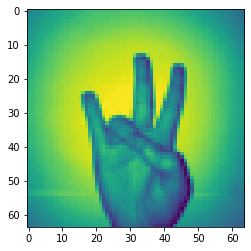

In [23]:
plt.imshow(xtest[1])

In [24]:
ytest[1] # Actual output of the input Xtest[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [25]:
img_classifier.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 512)               2097664   
                                                                 
 dense_1 (Dense)             (None, 256)               131328    
                                                                 
 dense_2 (Dense)             (None, 10)                2570      
                                                                 
Total params: 2231562 (8.51 MB)
Trainable params: 2231562 (8.51 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


input layer neurons = 4096

hidden layer-1 neurons = 512

Weights in the the first layer (b/w inp and hid1) = 4096*512 = 2097152

Bias in the first hidden layer = 512

Total number of parameter in the first layer = 4096*512 +512 = 2097664

Number of neurons in the second hidden layer = 256

Total number of parameter in the second layer(b/w hid 1 and hid 2) = 512*256 +256 = 131328

Number of neurons in the output layer = 10

Total number of parameter in the last layer(b/w hid 2 and output) = 256*10 +10 = 2570

In total this network need to train 2097664+131328+2570 = 2,231,562 parameters. 
